# Baseline Model Selection and Justification

This notebook presents the baseline modeling workflow for the project question:
whether lagged satellite summaries and lagged economic indicators can help predict **future metro-level economic change**.

The proposal and `MODELING_NEXT_STEPS.md` imply a time-aware panel baseline with:

- lagged predictors
- metro fixed effects
- train / validation / test split by year
- comparison across interpretable and nonlinear models

The notebook estimates three baseline models:

- **Linear Regression with metro fixed effects**
- **Ridge Regression on an expanded lagged panel**
- **Gradient Boosting Regressor**

The selected baseline for reporting is **Ridge Regression on the expanded lagged panel** because it offers the best held-out performance while remaining interpretable and well suited to a small, collinear predictor set. **Gradient Boosting** is retained as the main nonlinear Stat 109B comparison model, and **Linear Regression** serves as the simplest transparent reference.

The notebook focuses on one target, **`employment_thousands_growth`**, so that the baseline can be presented cleanly from start to finish before the same framework is extended to additional outcomes.

> **How far can we get with lagged raw satellite summaries and standard tabular baselines before the richer spatial features are ready?**

## Table of Contents

1. **[Baseline Model Selection and Justification](#1.-Baseline-Model-Selection-and-Justification)**:
   why these three models are included, and how they map to simplicity, interpretability, and project relevance.
2. **[Data Used for Training and Testing](#2.-Data-Used-for-Training-and-Testing)**:
   what data are used, what rows are excluded, and why the target distribution itself makes this forecasting problem difficult.
3. **[Forecasting Difficulty and Sanity Checks](#3.-Forecasting-Difficulty-and-Sanity-Checks)**:
   how target shift, naive persistence, and linear diagnostics help frame the forecasting task.
4. **[Training Protocol](#4.-Training-Protocol-for-the-Final-Baseline-Comparison)**:
   preprocessing, feature families, parameter choices, rolling validation, and evaluation metrics.
5. **[Results and Interpretation](#5.-Results-and-Interpretation)**:
   what the baseline results mean scientifically and how they connect back to the proposal.
6. **[Next Steps](#6.-Next-Steps)**:
   the immediate modeling steps that follow this baseline stage.

## Executive Summary

Three baseline models are compared in this notebook:
**Linear Regression with metro fixed effects**, **Ridge Regression on an expanded lagged panel**, and **Gradient Boosting Regressor**.

The selected model is **Ridge Regression on the expanded lagged panel** because it balances:

- the strongest held-out test performance in this comparison;
- a linear, still-interpretable structure;
- and better behavior under multicollinearity than an unregularized regression.

The main empirical takeaway is that lagged economic dynamics carry substantial predictive signal, while lagged raw satellite summaries add useful but still limited information. The notebook therefore establishes a clear raw-summary baseline for the project, while also showing that the later GHSL / built-up feature stage remains important.

## Project Context

This notebook fits into the broader project pipeline as the baseline modeling stage.

| Project component | Current status | What is already known |
| --- | --- | --- |
| **Data pipeline** | Completed | Satellite imagery, economic indicators, and the unified metro-year panel are already built. |
| **EDA** | Completed | Raw pixel summaries are weak across pooled cities, but within-metro temporal structure is meaningful. |
| **Raw-summary baseline modeling** | Completed in this notebook | Provides the reference results using lagged satellite summaries and lagged economic indicators. |
| **GHSL / built-up segmentation and spatial feature extraction** | Not yet completed | This is still the key missing ingredient for answering the full proposal. |
| **Final scientific comparison** | Pending | The key comparison will be whether built-up / urban-form features outperform the baseline established here. |

The role of this notebook is therefore specific:

- it defines the project's tabular baseline under the planned time split;
- it uses raw satellite summaries rather than explicit built-up spatial features;
- it establishes the reference results that later feature sets will be compared against.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings(
    "ignore",
    message="Skipping features without any observed values",
    category=UserWarning,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["legend.frameon"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.facecolor"] = "#fcfcfd"
plt.rcParams["grid.color"] = "#d0d7de"
plt.rcParams["grid.linewidth"] = 1.0
plt.rcParams["axes.edgecolor"] = "#c7ccd1"

pd.set_option("display.max_columns", 100)

DATA_PATH = Path("data/modeling/panel_features.csv")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model_palette = {
    "Linear Regression (fixed effects)": "#64748b",
    "Ridge Regression (expanded lagged panel)": "#0f766e",
    "Gradient Boosting Regressor": "#2563eb",
}

diagnostic_palette = {
    "Linear model: core lagged set": "#94a3b8",
    "Linear model: lagged-growth set": "#0f766e",
}

year_palette = {
    2021: "#6d28d9",
    2022: "#0f766e",
    2023: "#d97706",
}

group_palette = {
    "Lagged economic growth": "#0f766e",
    "Lagged economic levels": "#2563eb",
    "Lagged satellite summaries": "#64748b",
}


def display_table(df, caption=None, precision=3, left_align=None, highlight_rows=None):
    styler = df.style.format(precision=precision)
    if caption:
        styler = styler.set_caption(caption)
    styler = styler.set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-size", "14px"),
                    ("font-weight", "600"),
                    ("color", "#0f172a"),
                    ("margin-bottom", "6px"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#eef2f7"),
                    ("color", "#0f172a"),
                    ("font-weight", "600"),
                    ("border", "1px solid #d7dce2"),
                    ("padding", "7px 10px"),
                    ("text-align", "left"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #e5e7eb"),
                    ("padding", "7px 10px"),
                    ("vertical-align", "top"),
                    ("white-space", "normal"),
                ],
            },
        ]
    )
    if left_align is not None:
        styler = styler.set_properties(subset=left_align, **{"text-align": "left"})
    else:
        styler = styler.set_properties(**{"text-align": "left"})
    if highlight_rows is not None:
        def _highlight(row):
            if row.name in highlight_rows:
                return ["background-color: #ecfdf5; font-weight: 600"] * len(row)
            return [""] * len(row)
        styler = styler.apply(_highlight, axis=1)
    try:
        styler = styler.hide(axis="index")
    except Exception:
        try:
            styler = styler.hide_index()
        except Exception:
            pass
    display(styler)

## 1. Baseline Model Selection and Justification

The model set is chosen using the three criteria in the assignment prompt:

- **simplicity**: there should be at least one transparent benchmark;
- **interpretability**: we should be able to explain what the model is learning and why;
- **relevance to the project statement**: the model should make sense for forecasting future metro-level economic change from lagged satellite and economic signals.

| Model | Role in the notebook | Why it is included |
| --- | --- | --- |
| **Linear Regression with metro fixed effects** | Simple reference model | Closest to a classic panel-regression baseline. Metro dummies absorb level differences across cities. |
| **Ridge Regression on an expanded lagged panel** | Selected baseline | Retains a linear structure but is better suited to a small, highly collinear lagged feature set. |
| **Gradient Boosting Regressor** | Nonlinear Stat 109B comparison | Captures interactions and threshold effects while remaining standard and easy to justify as a baseline tree ensemble. |

We focus on **`employment_thousands_growth`** as the target because it best matches the proposal's "**future economic changes**" framing. Predicting growth is harder than predicting levels, but it is the more honest benchmark for this stage of the project.

We also deliberately keep the milestone scoped to **one target** rather than trying to model GDP, employment, and permits all at once. That tradeoff keeps the notebook readable and lets us build one benchmark carefully before scaling the exact same evaluation structure to the other outcomes.

The selected model is **Ridge Regression on the expanded lagged panel**. It is selected because it combines:

- the best held-out test metrics in the final comparison;
- a linear coefficient-based structure that remains interpretable;
- and regularization that is appropriate for correlated lagged predictors.

## 2. Data Used for Training and Testing

The project already provides a modeling panel in `data/modeling/panel_features.csv` with the intended time split:

- `train`: 2013-2018
- `val`: 2019
- `test`: 2021-2023
- `2020`: excluded because of COVID structural break

We begin from the **entire modeling panel** currently available in the repository. We do **not** randomly subsample metros or years. The only rows excluded from model fitting are rows where the target itself is undefined:

- the current panel contains **140 metro-year rows**;
- the first year for each metro has no year-over-year growth target, so **14 rows** are unavailable for this specific prediction task;
- the remaining **126 rows** are all retained;
- we do **not** drop additional rows for predictor missingness, because the panel is already small and imputation is a more appropriate baseline choice.

To make the baseline more faithful to the proposal, this notebook engineers **lag-1 versions** of both:

- raw satellite summary features
- economic growth features

That change matters. If the research question is about **future economic change**, then a good baseline should at least test whether **past economic change** and **past satellite summaries** help forecast the next period.

In [2]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


df = (
    pd.read_csv(DATA_PATH)
    .sort_values(["metro", "year"])
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

target = "employment_thousands_growth"
target_label = "Employment growth (%)"

raw_satellite_features = [
    "modis_brightness_mean",
    "modis_ndvi_proxy_mean",
    "modis_dark_frac",
    "viirs_mean",
    "viirs_lit_frac",
    "viirs_bright_frac",
    "viirs_gini",
]

expanded_satellite_features = [
    "modis_red_mean",
    "modis_red_std",
    "modis_green_mean",
    "modis_green_std",
    "modis_blue_mean",
    "modis_blue_std",
    "modis_brightness_std",
    "viirs_std",
    "viirs_median",
    "viirs_p90",
    "viirs_max",
    "modis_brightness_mean_delta",
    "modis_ndvi_proxy_mean_delta",
    "modis_dark_frac_delta",
    "viirs_mean_delta",
    "viirs_lit_frac_delta",
    "viirs_bright_frac_delta",
    "modis_brightness_mean_growth",
    "viirs_mean_growth",
]

level_features = [
    "gdp_millions",
    "employment_thousands",
    "unemployment_rate",
    "total_permits",
    "gdp_per_employee",
    "permits_per_1k_emp",
]

growth_features = [
    "employment_thousands_growth",
    "gdp_millions_growth",
    "total_permits_growth",
]

for column in raw_satellite_features + expanded_satellite_features + level_features + growth_features:
    if column in df.columns:
        df[f"{column}_lag1_manual"] = df.groupby("metro")[column].shift(1)

current_numeric_features = [
    "modis_brightness_mean_lag1_manual",
    "modis_ndvi_proxy_mean_lag1_manual",
    "modis_dark_frac_lag1_manual",
    "viirs_mean_lag1_manual",
    "viirs_lit_frac_lag1_manual",
    "viirs_bright_frac_lag1_manual",
    "viirs_gini_lag1_manual",
    "gdp_millions_lag1",
    "employment_thousands_lag1",
    "unemployment_rate_lag1",
    "total_permits_lag1",
]

enhanced_numeric_features = current_numeric_features + [
    "employment_thousands_growth_lag1_manual",
    "gdp_millions_growth_lag1_manual",
    "total_permits_growth_lag1_manual",
]

expanded_candidate_numeric_features = [
    f"{column}_lag1_manual"
    for column in raw_satellite_features + expanded_satellite_features + level_features + growth_features
    if f"{column}_lag1_manual" in df.columns
]

categorical_features = ["metro"]

panel_df = df[df["year"] != 2020].copy()
panel_df = panel_df[panel_df[target].notna()].copy()

train_df = panel_df[panel_df["split"] == "train"].copy()
val_df = panel_df[panel_df["split"] == "val"].copy()
test_df = panel_df[panel_df["split"] == "test"].copy()

pruned_expanded_numeric_features = [
    feature
    for feature in expanded_candidate_numeric_features
    if train_df[feature].notna().mean() > 0.25
]

split_summary = (
    panel_df.groupby("split")
    .agg(
        rows=("metro", "size"),
        metros=("metro", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

setup_summary = pd.DataFrame(
    [
        {"Item": "Full modeling panel", "Value": f"{len(df)} metro-year observations"},
        {"Item": "Rows with defined growth target", "Value": f"{len(panel_df)} metro-year observations"},
        {"Item": "Target", "Value": "employment_thousands_growth"},
        {"Item": "Current baseline feature count", "Value": len(current_numeric_features)},
        {"Item": "Enhanced feature count", "Value": len(enhanced_numeric_features)},
        {"Item": "Expanded lagged candidates", "Value": len(expanded_candidate_numeric_features)},
        {"Item": "Expanded lagged features retained", "Value": len(pruned_expanded_numeric_features)},
    ]
)

data_flow_summary = pd.DataFrame(
    [
        {"Stage": "Full modeling panel", "Rows": len(df), "Reason": "Entire panel currently available in the repo"},
        {
            "Stage": "Rows removed before modeling",
            "Rows": len(df) - len(panel_df),
            "Reason": "Growth target undefined in the first year of each metro",
        },
        {
            "Stage": "Rows used for this notebook",
            "Rows": len(panel_df),
            "Reason": "All remaining rows retained; missing predictors handled by imputation",
        },
    ]
)

feature_group_table = pd.DataFrame(
    [
        {
            "Feature family": "Conservative enhanced baseline",
            "Columns retained": "11 lagged satellite + economic-level features, plus 3 lagged growth terms",
            "Why it exists": "Compact lagged panel for transparent baseline models",
        },
        {
            "Feature family": "Expanded lagged panel",
            "Columns retained": f"{len(expanded_candidate_numeric_features)} candidate lagged features before pruning",
            "Why it exists": "Adds richer raw-pixel summaries, changes, and economic ratios",
        },
        {
            "Feature family": "Pruned expanded lagged panel",
            "Columns retained": f"{len(pruned_expanded_numeric_features)} retained after training-split non-missing share > 25%",
            "Why it exists": "Keeps the broader panel but removes ultra-sparse predictors before regularized modeling",
        },
        {
            "Feature family": "Metro fixed effects",
            "Columns retained": "metro (one-hot encoded)",
            "Why it exists": "Absorbs cross-city level differences in the panel",
        },
    ]
)

missingness_table = (
    train_df[expanded_candidate_numeric_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .reset_index()
    .rename(columns={"index": "feature"})
    .head(12)
)

target_shift_summary = (
    panel_df.groupby("split")[target]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

test_year_summary = (
    test_df.groupby("year")[target]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"year": "Test year"})
)

display_table(
    setup_summary,
    caption="Notebook scope at a glance",
    precision=0,
    left_align=["Item", "Value"],
)
display_table(
    data_flow_summary,
    caption="How the full panel is filtered for this prediction task",
    precision=0,
    left_align=["Stage", "Reason"],
)
display_table(
    split_summary,
    caption="Time-based train / validation / test split",
    precision=0,
    left_align=["Dataset split"],
)
display_table(
    feature_group_table,
    caption="Feature families used in the final baseline comparison",
    left_align=["Feature family", "Columns retained", "Why it exists"],
)
display_table(
    missingness_table.round(3),
    caption="Highest training-split missingness rates among expanded lagged candidates",
    precision=3,
    left_align=["feature"],
)
display_table(
    target_shift_summary.round(3),
    caption="Target distribution by split: the held-out period is much more volatile than the training years",
    precision=3,
    left_align=["Dataset split"],
)
display_table(
    test_year_summary.round(3),
    caption="Held-out employment-growth distribution by year",
    precision=3,
    left_align=["Test year"],
)

Item,Value
Full modeling panel,140 metro-year observations
Rows with defined growth target,126 metro-year observations
Target,employment_thousands_growth
Current baseline feature count,11
Enhanced feature count,14
Expanded lagged candidates,35
Expanded lagged features retained,29


Stage,Rows,Reason
Full modeling panel,140,Entire panel currently available in the repo
Rows removed before modeling,14,Growth target undefined in the first year of each metro
Rows used for this notebook,126,All remaining rows retained; missing predictors handled by imputation


Dataset split,rows,metros,first_year,last_year
test,42,14,2021,2023
train,70,14,2014,2018
val,14,14,2019,2019


Feature family,Columns retained,Why it exists
Conservative enhanced baseline,"11 lagged satellite + economic-level features, plus 3 lagged growth terms",Compact lagged panel for transparent baseline models
Expanded lagged panel,35 candidate lagged features before pruning,"Adds richer raw-pixel summaries, changes, and economic ratios"
Pruned expanded lagged panel,29 retained after training-split non-missing share > 25%,Keeps the broader panel but removes ultra-sparse predictors before regularized modeling
Metro fixed effects,metro (one-hot encoded),Absorbs cross-city level differences in the panel


feature,missing_share
viirs_mean_growth_lag1_manual,1.000
viirs_lit_frac_delta_lag1_manual,1.000
viirs_bright_frac_delta_lag1_manual,1.000
viirs_lit_frac_lag1_manual,0.800
viirs_bright_frac_lag1_manual,0.800
viirs_gini_lag1_manual,0.800
total_permits_growth_lag1_manual,0.271
modis_brightness_mean_delta_lag1_manual,0.200
viirs_mean_delta_lag1_manual,0.200
modis_brightness_mean_growth_lag1_manual,0.200


Dataset split,count,mean,std,min,max
test,42,2.863,3.027,-6.807,8.825
train,70,2.949,0.975,0.920,6.557
val,14,2.536,0.832,1.339,3.932


Test year,count,mean,std,min,max
2021,14,0.135,3.017,-6.807,5.763
2022,14,5.589,1.701,2.928,8.825
2023,14,2.866,0.942,1.008,4.069


## 3. Forecasting Difficulty and Sanity Checks

Before comparing the final three baselines, the notebook establishes why this forecasting task is difficult and what a reasonable baseline should capture.

First, it evaluates a **naive persistence rule**:
"next year's employment growth will look like last year's."
This is a useful sanity check because the formal validation set is only one year (`2019`), and a single calm year can make a simple rule look stronger than it really is.

Second, it compares two linear specifications:
one using a compact lagged feature set, and one that also includes lagged economic-growth terms.

Together, these checks clarify four issues:

- how different the train, validation, and held-out target distributions are;
- whether a **single validation year** is enough to guide model choice;
- whether lagged economic dynamics add useful predictive signal;
- and how much room there is for a nonlinear model to add value beyond linear structure.

/var/folders/9m/38wwfmhs1q9cyk9nrpz4dczh0000gn/T/ipykernel_41991/1295444296.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


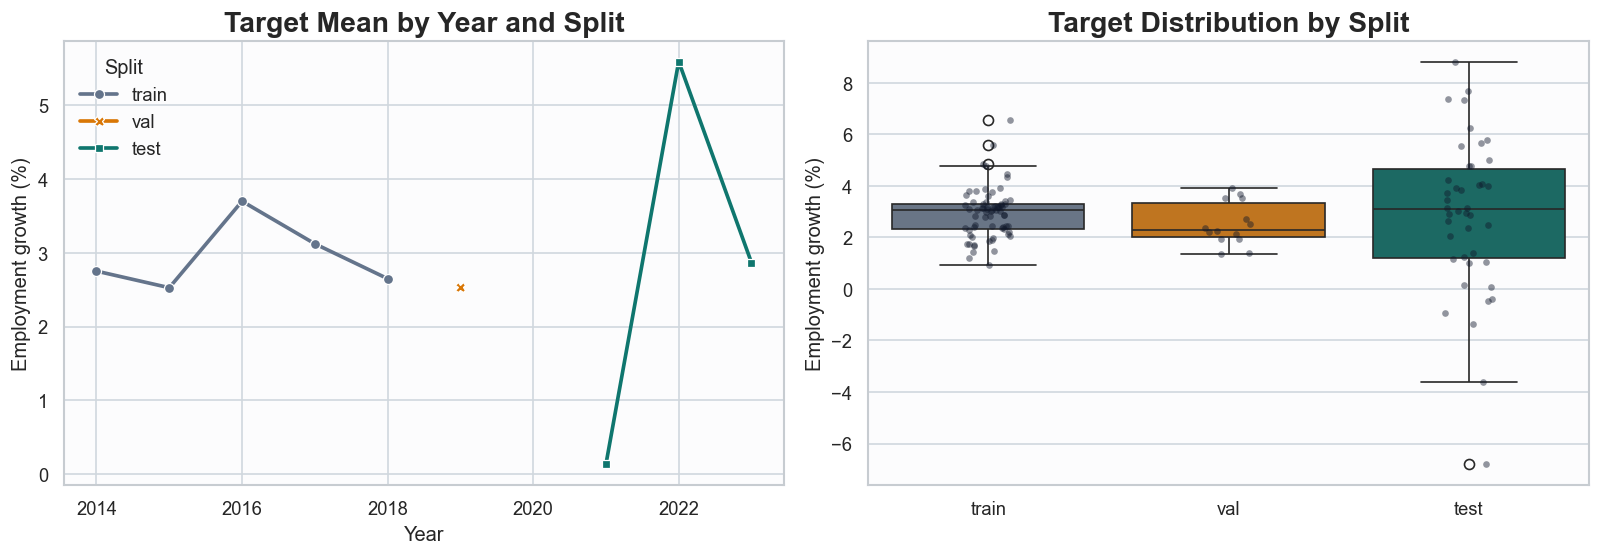

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

yearly_target = (
    panel_df.groupby(["year", "split"])[target]
    .agg(["mean", "std"])
    .reset_index()
)
split_order = ["train", "val", "test"]
split_color_map = {
    "train": "#64748b",
    "val": "#d97706",
    "test": "#0f766e",
}

sns.lineplot(
    data=yearly_target,
    x="year",
    y="mean",
    hue="split",
    style="split",
    markers=True,
    dashes=False,
    hue_order=split_order,
    palette=split_color_map,
    linewidth=2.2,
    ax=axes[0],
)
axes[0].set_title("Target Mean by Year and Split")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Employment growth (%)")
axes[0].legend(title="Split", loc="upper left")

sns.boxplot(
    data=panel_df,
    x="split",
    y=target,
    order=split_order,
    palette=split_color_map,
    ax=axes[1],
)
sns.stripplot(
    data=panel_df,
    x="split",
    y=target,
    order=split_order,
    color="#0f172a",
    alpha=0.45,
    size=4,
    ax=axes[1],
)
axes[1].set_title("Target Distribution by Split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Employment growth (%)")

plt.tight_layout()
plt.show()

Model,Split,R2,RMSE,MAE
Naive persistence benchmark,Validation,0.832,0.329,0.272
Naive persistence benchmark,Test,-1.497,4.727,3.645


Model,Split,R2,RMSE,MAE
Linear model: core lagged set,Validation,-5.344,2.020,1.714
Linear model: core lagged set,Test,0.098,2.841,2.167
Linear model: lagged-growth set,Validation,-4.777,1.927,1.605
Linear model: lagged-growth set,Test,0.142,2.771,2.100


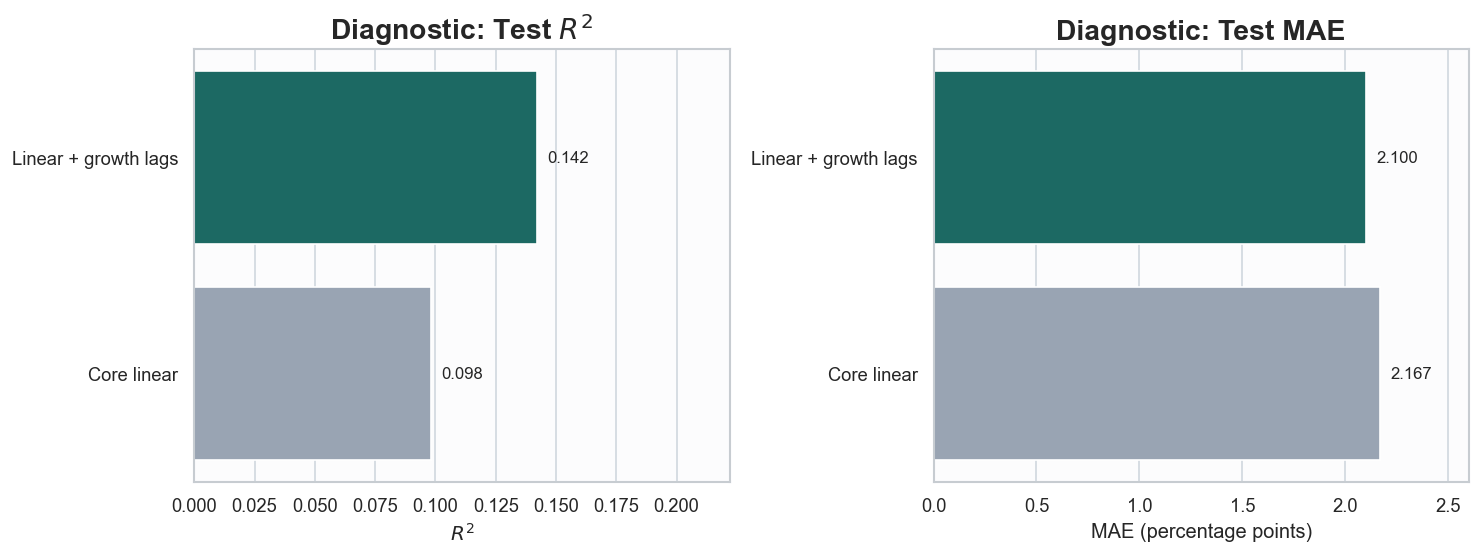

In [4]:
def make_linear_pipeline(numeric_features):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler()),
                                ]
                            ),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", LinearRegression()),
        ]
    )


persistence_rows = []
for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
    valid_rows = split_df[split_df["employment_thousands_growth_lag1_manual"].notna()].copy()
    persistence_pred = valid_rows["employment_thousands_growth_lag1_manual"]
    persistence_rows.append(
        {
            "Model": "Naive persistence benchmark",
            "Split": split_name,
            "R2": r2_score(valid_rows[target], persistence_pred),
            "RMSE": rmse(valid_rows[target], persistence_pred),
            "MAE": mean_absolute_error(valid_rows[target], persistence_pred),
        }
    )

persistence_results = pd.DataFrame(persistence_rows).round(3)
display_table(
    persistence_results,
    caption="Sanity check: a one-year persistence rule looks strong on 2019 but fails on the true held-out period",
    precision=3,
    left_align=["Model", "Split"],
)

diagnostic_rows = []
diagnostic_models = {
    "Linear model: core lagged set": current_numeric_features,
    "Linear model: lagged-growth set": enhanced_numeric_features,
}

for label, numeric_features in diagnostic_models.items():
    pipeline = make_linear_pipeline(numeric_features)
    pipeline.fit(train_df[categorical_features + numeric_features], train_df[target])

    for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
        predictions = pipeline.predict(split_df[categorical_features + numeric_features])
        diagnostic_rows.append(
            {
        "Model": label,
        "Split": split_name,
                "R2": r2_score(split_df[target], predictions),
                "RMSE": rmse(split_df[target], predictions),
                "MAE": mean_absolute_error(split_df[target], predictions),
            }
        )

diagnostic_results = pd.DataFrame(diagnostic_rows).round(3)
display_table(
    diagnostic_results,
    caption="Diagnostic comparison: does a better linear feature set help?",
    precision=3,
    left_align=["Model", "Split"],
)

diagnostic_test = diagnostic_results[diagnostic_results["Split"] == "Test"].copy()
diagnostic_test["Plot label"] = diagnostic_test["Model"].map(
    {
        "Linear model: core lagged set": "Core linear",
        "Linear model: lagged-growth set": "Linear + growth lags",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

sns.barplot(
    data=diagnostic_test,
    y="Plot label",
    x="R2",
    order=["Linear + growth lags", "Core linear"],
    hue="Model",
    palette=diagnostic_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Diagnostic: Test $R^2$")
axes[0].set_xlabel("$R^2$")
axes[0].set_ylabel("")
axes[0].set_xlim(0, diagnostic_test["R2"].max() + 0.08)

sns.barplot(
    data=diagnostic_test,
    y="Plot label",
    x="MAE",
    order=["Linear + growth lags", "Core linear"],
    hue="Model",
    palette=diagnostic_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Diagnostic: Test MAE")
axes[1].set_xlabel("MAE (percentage points)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, diagnostic_test["MAE"].max() * 1.20)

for ax in axes:
    xmin, xmax = ax.get_xlim()
    offset = 0.02 * (xmax - xmin)
    for patch in ax.patches:
        x = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(x + offset, y, f"{x:.3f}", ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Training Protocol for the Final Baseline Comparison

The final comparison uses two feature families:

- **Linear Regression (fixed effects)** and **Gradient Boosting** use a compact lagged feature set:
  lagged raw satellite summaries, lagged economic levels, lagged economic growth terms, and metro fixed effects.
- **Ridge Regression** uses a broader pruned expanded lagged panel:
  richer lagged satellite summaries, lagged changes, lagged economic ratios, lagged growth terms, and metro fixed effects.

This design keeps the comparison readable while still letting the selected model use a richer lagged panel. The raw-satellite feature space is small and highly collinear, so a regularized linear model is a natural choice for the broader specification.

**Evaluation protocol**

The project plan already specifies `2019` as the formal validation year, so we keep that split. But because a single validation year is fragile for such a small panel, we also add a **rolling-origin validation check**:

- train on years before 2016, validate on 2016
- train on years before 2017, validate on 2017
- train on years before 2018, validate on 2018

That rolling check does not replace the official split. It is included to answer a practical model-selection question:

> **Which model looks most stable across several historical holdout years, not just one?**

The persistence sanity check shows why this matters: a model can look good on `2019` and still generalize poorly to the true held-out period.

**Preprocessing**

- numeric features: median imputation
- metro identifier: one-hot encoding to create fixed effects
- scaling: applied to the linear models
- sparsity control for the expanded lagged panel: retain only features with training-split non-missing share above `25%`
- leakage control: every predictive feature is lagged, and the split is purely time-based rather than randomly shuffled

**Parameter choices and light tuning**

The point of this notebook is to build a credible benchmark, not to exhaustively optimize a small panel:

| Model | Key settings | Why these settings were used |
| --- | --- | --- |
| **Linear Regression** | default linear model after scaling | maximally transparent fixed-effects-style reference |
| **Ridge Regression** | `alpha=1.0` | default-strength regularization for a wider, correlated lagged panel |
| **Gradient Boosting** | `n_estimators=150`, `learning_rate=0.05`, `max_depth=2` | shallow boosting setup that stays conservative on a small panel |

**Evaluation metrics**

- **R²**: how much variation in employment growth is explained
- **RMSE**: penalizes larger forecasting errors more heavily
- **MAE**: easiest to interpret as average prediction error in percentage points

Because the test period is heterogeneous, the notebook also reports **year-by-year diagnostics** for the selected model rather than relying on one pooled scatter alone.

In [5]:
def make_tree_pipeline(numeric_features, estimator):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", estimator),
        ]
    )


def make_ridge_pipeline(numeric_features, alpha=1.0):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler()),
                                ]
                            ),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", Ridge(alpha=alpha)),
        ]
    )


candidate_models = {
    "Linear Regression (fixed effects)": {
        "pipeline": make_linear_pipeline(enhanced_numeric_features),
        "features": enhanced_numeric_features,
        "feature_family": "Conservative enhanced lagged panel",
        "role": "Transparent fixed-effects reference",
    },
    "Ridge Regression (expanded lagged panel)": {
        "pipeline": make_ridge_pipeline(pruned_expanded_numeric_features, alpha=1.0),
        "features": pruned_expanded_numeric_features,
        "feature_family": "Pruned expanded lagged panel",
        "role": "Selected baseline",
    },
    "Gradient Boosting Regressor": {
        "pipeline": make_tree_pipeline(
            enhanced_numeric_features,
            GradientBoostingRegressor(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=2,
                random_state=42,
            ),
        ),
        "features": enhanced_numeric_features,
        "feature_family": "Conservative enhanced lagged panel",
        "role": "Nonlinear Stat 109B comparison",
    },
}

rolling_years = [2016, 2017, 2018]
comparison_order = [
    "Linear Regression (fixed effects)",
    "Ridge Regression (expanded lagged panel)",
    "Gradient Boosting Regressor",
]

rows = []
rolling_detail_rows = []
fitted_models = {}
prediction_store = {}

for model_name, spec in candidate_models.items():
    pipeline = spec["pipeline"]
    numeric_features = spec["features"]
    rolling_scores = []
    for holdout_year in rolling_years:
        rolling_train = panel_df[(panel_df["year"] < holdout_year) & (panel_df["split"] == "train")].copy()
        rolling_valid = panel_df[(panel_df["year"] == holdout_year) & (panel_df["split"] == "train")].copy()

        pipeline.fit(
            rolling_train[categorical_features + numeric_features],
            rolling_train[target],
        )
        rolling_pred = pipeline.predict(
            rolling_valid[categorical_features + numeric_features]
        )
        rolling_scores.append(
            {
                "year": holdout_year,
                "r2": r2_score(rolling_valid[target], rolling_pred),
                "rmse": rmse(rolling_valid[target], rolling_pred),
                "mae": mean_absolute_error(rolling_valid[target], rolling_pred),
            }
        )
        rolling_detail_rows.append(
            {
                "Model": model_name,
                "Holdout year": holdout_year,
                "R2": r2_score(rolling_valid[target], rolling_pred),
                "RMSE": rmse(rolling_valid[target], rolling_pred),
                "MAE": mean_absolute_error(rolling_valid[target], rolling_pred),
            }
        )

    rolling_df = pd.DataFrame(rolling_scores)

    pipeline.fit(
        train_df[categorical_features + numeric_features],
        train_df[target],
    )
    fitted_models[model_name] = pipeline

    val_pred = pipeline.predict(val_df[categorical_features + numeric_features])
    test_pred = pipeline.predict(test_df[categorical_features + numeric_features])

    prediction_store[(model_name, "Validation")] = val_pred
    prediction_store[(model_name, "Test")] = test_pred

    rows.append(
        {
            "Model": model_name,
            "Feature family": spec["feature_family"],
            "Role": spec["role"],
            "Rolling CV Mean R2": rolling_df["r2"].mean(),
            "Rolling CV Mean MAE": rolling_df["mae"].mean(),
            "Validation R2": r2_score(val_df[target], val_pred),
            "Validation MAE": mean_absolute_error(val_df[target], val_pred),
            "Test R2": r2_score(test_df[target], test_pred),
            "Test MAE": mean_absolute_error(test_df[target], test_pred),
            "Test RMSE": rmse(test_df[target], test_pred),
        }
    )

comparison_results = pd.DataFrame(rows)
comparison_results["order"] = comparison_results["Model"].map(
    {model_name: idx for idx, model_name in enumerate(comparison_order)}
)
comparison_results = comparison_results.sort_values("order").drop(columns="order").reset_index(drop=True)

benchmark_model_name = "Ridge Regression (expanded lagged panel)"
stability_model_name = "Gradient Boosting Regressor"

comparison_results_display = comparison_results.copy()
comparison_results_display.insert(
    1,
    "Highlight",
    comparison_results_display["Model"].map(
        lambda value: (
            "Current benchmark"
            if value == benchmark_model_name
            else "Most stable pre-period model"
            if value == stability_model_name
            else ""
        )
    ),
)
display_table(
    comparison_results_display.round(3),
    caption="Improved baseline comparison: conservative references plus the upgraded regularized benchmark",
    precision=3,
    left_align=["Model", "Highlight", "Feature family", "Role"],
    highlight_rows=[
        comparison_results_display.index[
            comparison_results_display["Model"] == benchmark_model_name
        ][0]
    ],
)

benchmark_summary = pd.DataFrame(
    [
        {
            "Selected model": benchmark_model_name,
            "Test R2": comparison_results.loc[
                comparison_results["Model"] == benchmark_model_name, "Test R2"
            ].iloc[0],
            "Test MAE": comparison_results.loc[
                comparison_results["Model"] == benchmark_model_name, "Test MAE"
            ].iloc[0],
            "Why it is selected": "It produces the strongest held-out test performance while remaining interpretable and well matched to a collinear lagged panel.",
            "Complementary note": "Gradient Boosting remains the most stable nonlinear model across the rolling pre-period validation years.",
        }
    ]
)
display_table(
    benchmark_summary,
    caption="How to read the final comparison table",
    precision=3,
    left_align=["Selected model", "Why it is selected", "Complementary note"],
)

rolling_results = pd.DataFrame(rolling_detail_rows)
rolling_mae_table = (
    rolling_results.pivot(index="Holdout year", columns="Model", values="MAE")
    .reset_index()
    .round(3)
)
display_table(
    rolling_mae_table,
    caption="Rolling-origin validation MAE by holdout year",
    precision=3,
    left_align=["Holdout year"],
)

Model,Highlight,Feature family,Role,Rolling CV Mean R2,Rolling CV Mean MAE,Validation R2,Validation MAE,Test R2,Test MAE,Test RMSE
Linear Regression (fixed effects),,Conservative enhanced lagged panel,Transparent fixed-effects reference,-1.122,1.129,-4.777,1.605,0.142,2.100,2.771
Ridge Regression (expanded lagged panel),Current benchmark,Pruned expanded lagged panel,Selected baseline,-1.504,1.164,-0.266,0.772,0.233,1.843,2.620
Gradient Boosting Regressor,Most stable pre-period model,Conservative enhanced lagged panel,Nonlinear Stat 109B comparison,-0.293,0.873,0.139,0.593,0.180,1.936,2.709


Selected model,Test R2,Test MAE,Why it is selected,Complementary note
Ridge Regression (expanded lagged panel),0.233,1.843,It produces the strongest held-out test performance while remaining interpretable and well matched to a collinear lagged panel.,Gradient Boosting remains the most stable nonlinear model across the rolling pre-period validation years.


Holdout year,Gradient Boosting Regressor,Linear Regression (fixed effects),Ridge Regression (expanded lagged panel)
2016,1.417,1.663,1.546
2017,0.455,0.908,0.998
2018,0.746,0.818,0.948


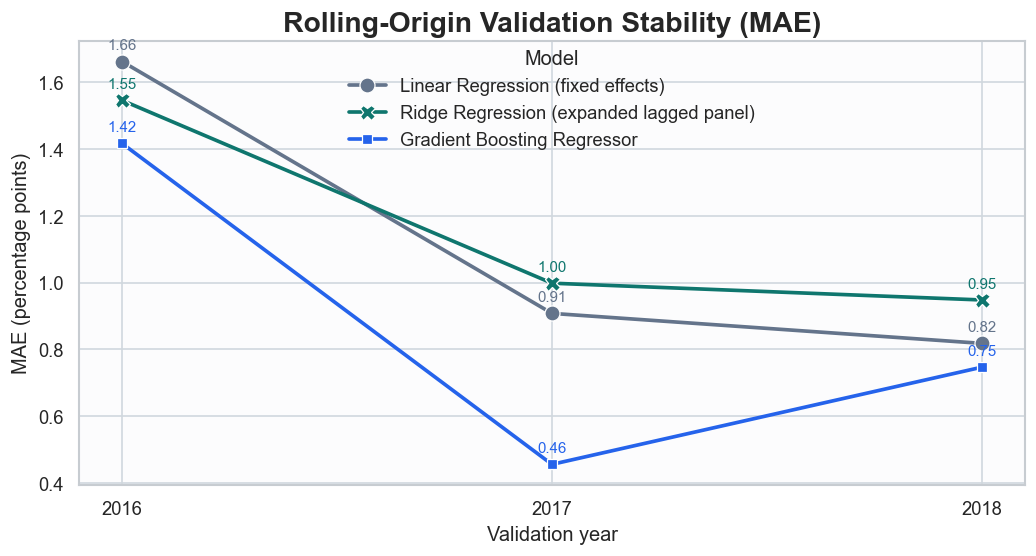

In [6]:
plt.figure(figsize=(8.8, 4.8))
ax = sns.lineplot(
    data=rolling_results,
    x="Holdout year",
    y="MAE",
    hue="Model",
    style="Model",
    markers=True,
    dashes=False,
    palette=model_palette,
    linewidth=2.2,
    markersize=9,
)
ax.set_title("Rolling-Origin Validation Stability (MAE)")
ax.set_xlabel("Validation year")
ax.set_ylabel("MAE (percentage points)")
ax.set_xticks(sorted(rolling_results["Holdout year"].unique()))
ax.legend(title="Model", loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=1)
ymin, ymax = ax.get_ylim()
yoffset = 0.02 * (ymax - ymin)
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(
            x,
            y + yoffset,
            f"{y:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=line.get_color(),
        )
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_rolling_validation_stability.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

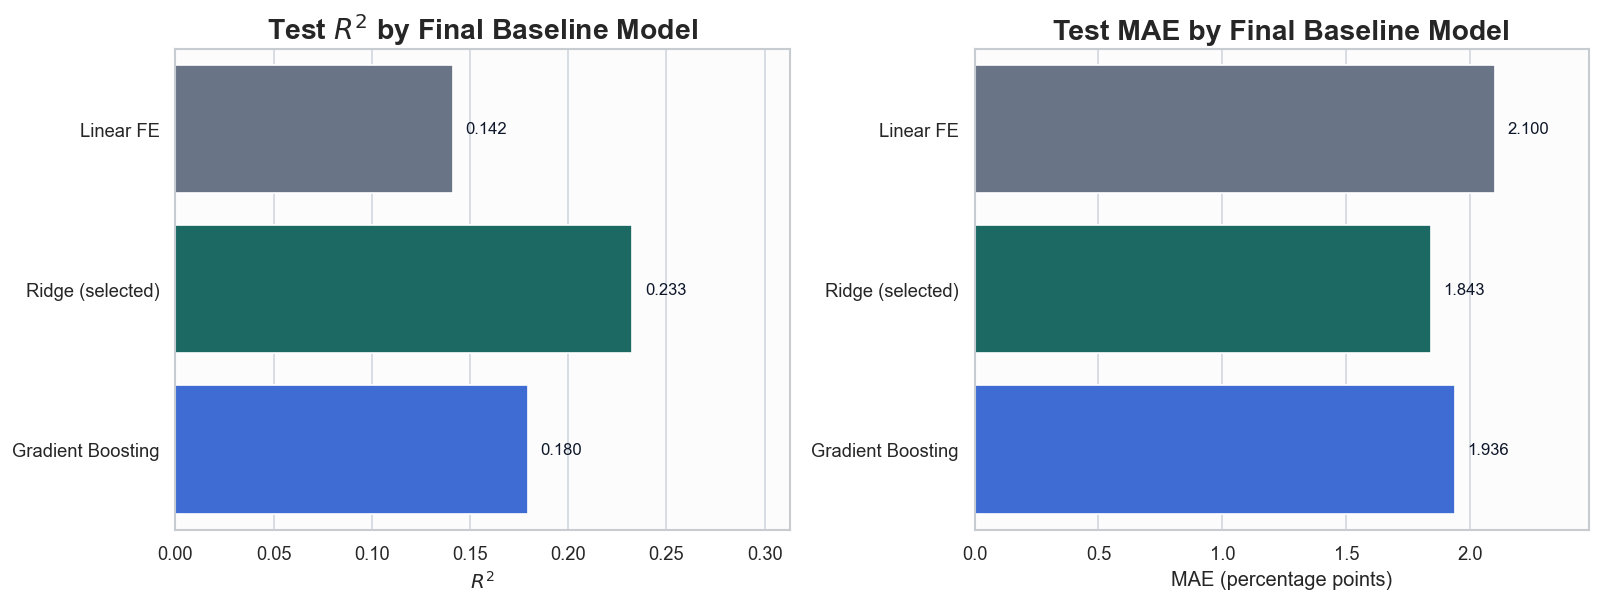

In [7]:
def annotate_bars(ax, decimals=3):
    xmin, xmax = ax.get_xlim()
    offset = 0.02 * (xmax - xmin)
    for patch in ax.patches:
        value = patch.get_width()
        x = value
        y = patch.get_y() + patch.get_height() / 2
        ax.text(
            x + offset,
            y,
            f"{value:.{decimals}f}",
            ha="left",
            va="center",
            fontsize=10,
            color="#0f172a",
        )


plot_order = comparison_results["Model"].tolist()
plot_labels = {
    "Linear Regression (fixed effects)": "Linear FE",
    "Ridge Regression (expanded lagged panel)": "Ridge (selected)",
    "Gradient Boosting Regressor": "Gradient Boosting",
}
comparison_plot = comparison_results.copy()
comparison_plot["Plot label"] = comparison_plot["Model"].map(plot_labels)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

sns.barplot(
    data=comparison_plot,
    y="Plot label",
    x="Test R2",
    order=[plot_labels[name] for name in plot_order],
    hue="Model",
    palette=model_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Test $R^2$ by Final Baseline Model")
axes[0].set_xlabel("$R^2$")
axes[0].set_ylabel("")
axes[0].set_xlim(0, comparison_results["Test R2"].max() + 0.08)
annotate_bars(axes[0], decimals=3)

sns.barplot(
    data=comparison_plot,
    y="Plot label",
    x="Test MAE",
    order=[plot_labels[name] for name in plot_order],
    hue="Model",
    palette=model_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Test MAE by Final Baseline Model")
axes[1].set_xlabel("MAE (percentage points)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, comparison_results["Test MAE"].max() * 1.18)
annotate_bars(axes[1], decimals=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_baseline_model_comparison.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

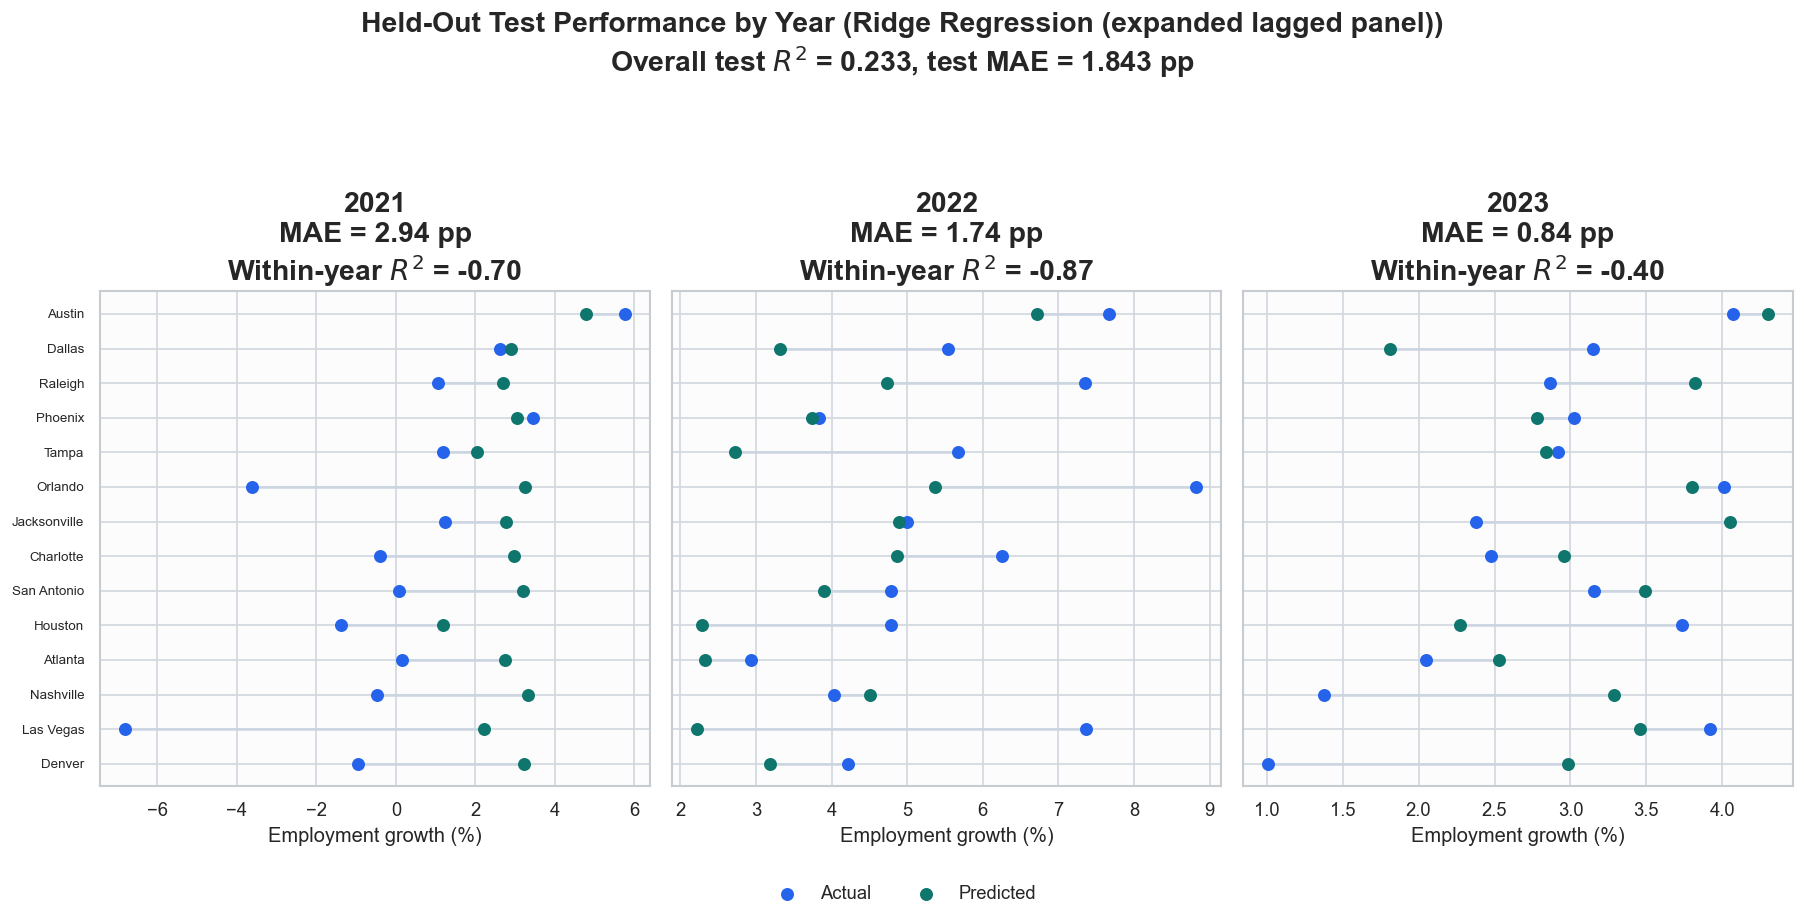

Test year,MAE,RMSE,Within-year R2
2021,2.939,3.795,-0.704
2022,1.744,2.244,-0.874
2023,0.845,1.074,-0.400


In [8]:
benchmark_model = fitted_models[benchmark_model_name]
benchmark_test_pred = prediction_store[(benchmark_model_name, "Test")]
benchmark_row = comparison_results[comparison_results["Model"] == benchmark_model_name].iloc[0]

prediction_df = test_df[["metro", "year", target]].copy()
prediction_df["prediction"] = benchmark_test_pred
prediction_df["metro_label"] = prediction_df["metro"].str.replace("_", " ").str.title()
metro_order = (
    prediction_df.groupby("metro_label")[target]
    .mean()
    .sort_values(ascending=True)
    .index
    .tolist()
)

year_metric_rows = []
for year, group in prediction_df.groupby("year"):
    year_metric_rows.append(
        {
            "Test year": year,
            "MAE": mean_absolute_error(group[target], group["prediction"]),
            "RMSE": rmse(group[target], group["prediction"]),
            "Within-year R2": r2_score(group[target], group["prediction"]),
        }
    )
benchmark_year_metrics = pd.DataFrame(year_metric_rows).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 7.2), sharex=False)
actual_color = "#2563eb"
predicted_color = "#0f766e"

for ax, year in zip(axes, [2021, 2022, 2023]):
    year_df = (
        prediction_df[prediction_df["year"] == year]
        .set_index("metro_label")
        .reindex(metro_order)
        .reset_index()
    )
    y_positions = np.arange(len(year_df))
    ax.hlines(
        y_positions,
        year_df[target],
        year_df["prediction"],
        color="#cbd5e1",
        linewidth=1.5,
    )
    ax.scatter(
        year_df[target],
        y_positions,
        color=actual_color,
        s=46,
        label="Actual" if year == 2021 else None,
        zorder=3,
    )
    ax.scatter(
        year_df["prediction"],
        y_positions,
        color=predicted_color,
        s=46,
        label="Predicted" if year == 2021 else None,
        zorder=3,
    )
    year_mae = benchmark_year_metrics.loc[
        benchmark_year_metrics["Test year"] == year, "MAE"
    ].iloc[0]
    year_r2 = benchmark_year_metrics.loc[
        benchmark_year_metrics["Test year"] == year, "Within-year R2"
    ].iloc[0]
    ax.set_title(f"{year}\nMAE = {year_mae:.2f} pp\nWithin-year $R^2$ = {year_r2:.2f}")
    ax.set_xlabel("Employment growth (%)")
    ax.set_yticks(y_positions)
    if year == 2021:
        ax.set_yticklabels(year_df["metro_label"], fontsize=8)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2)
fig.suptitle(
    f"Held-Out Test Performance by Year ({benchmark_model_name})\n"
    f"Overall test $R^2$ = {benchmark_row['Test R2']:.3f}, "
    f"test MAE = {benchmark_row['Test MAE']:.3f} pp",
    fontsize=17,
    fontweight="semibold",
    y=1.03,
)
plt.tight_layout(rect=(0, 0.04, 1, 0.95))
plt.savefig(FIGURES_DIR / "10_benchmark_yearwise_performance.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

display_table(
    benchmark_year_metrics,
    caption="Year-by-year held-out performance for the selected baseline, including within-year R2",
    precision=3,
    left_align=["Test year"],
)

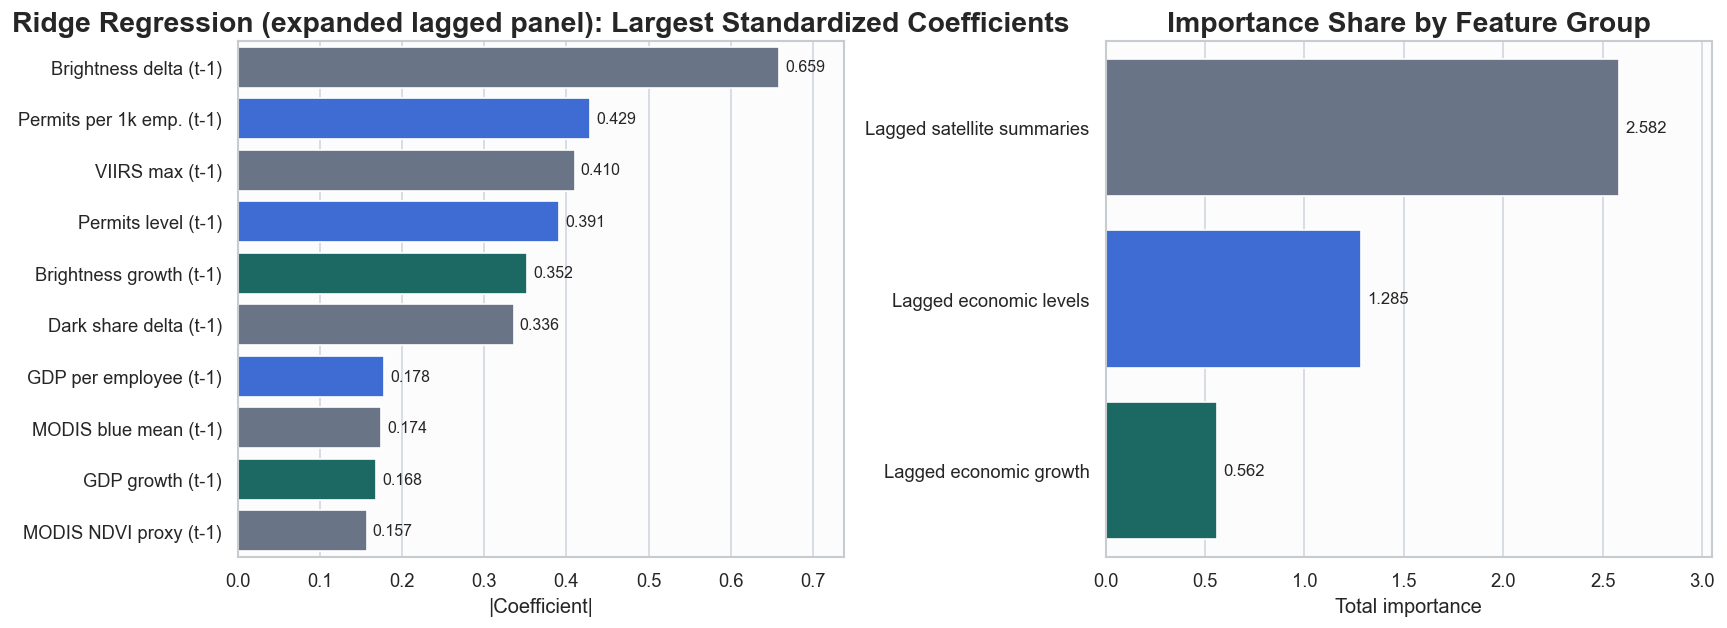

display_feature,group,importance
Brightness delta (t-1),Lagged satellite summaries,0.6587
Permits per 1k emp. (t-1),Lagged economic levels,0.4293
VIIRS max (t-1),Lagged satellite summaries,0.4099
Permits level (t-1),Lagged economic levels,0.3908
Brightness growth (t-1),Lagged economic growth,0.3525
Dark share delta (t-1),Lagged satellite summaries,0.3357
GDP per employee (t-1),Lagged economic levels,0.1784
MODIS blue mean (t-1),Lagged satellite summaries,0.1742
GDP growth (t-1),Lagged economic growth,0.1683
MODIS NDVI proxy (t-1),Lagged satellite summaries,0.1568


group,importance
Lagged satellite summaries,2.5821
Lagged economic levels,1.2849
Lagged economic growth,0.5618


In [9]:
def get_feature_names(preprocessor):
    names = []
    for transformer_name, transformer, cols in preprocessor.transformers_:
        if transformer_name == "num":
            names.extend(list(cols))
        elif transformer_name == "cat":
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    cat_names = transformer.get_feature_names_out(cols)
                except TypeError:
                    cat_names = transformer.get_feature_names(cols)
            else:
                cat_names = transformer.get_feature_names(cols)
            names.extend(list(cat_names))
    return names


def feature_group(feature_name):
    if "growth_lag1" in feature_name:
        return "Lagged economic growth"
    if any(
        token in feature_name
        for token in [
            "gdp_millions_lag1",
            "employment_thousands_lag1",
            "unemployment_rate_lag1",
            "total_permits_lag1",
            "gdp_per_employee",
            "permits_per_1k_emp",
        ]
    ):
        return "Lagged economic levels"
    return "Lagged satellite summaries"


benchmark_estimator = benchmark_model.named_steps["model"]
preprocessor = benchmark_model.named_steps["preprocessor"]

feature_label_map = {
    "gdp_millions_growth_lag1_manual": "GDP growth (t-1)",
    "employment_thousands_growth_lag1_manual": "Employment growth (t-1)",
    "total_permits_growth_lag1_manual": "Permits growth (t-1)",
    "gdp_millions_lag1": "GDP level (t-1)",
    "employment_thousands_lag1": "Employment level (t-1)",
    "unemployment_rate_lag1": "Unemployment rate (t-1)",
    "total_permits_lag1": "Permits level (t-1)",
    "modis_brightness_mean_lag1_manual": "MODIS brightness (t-1)",
    "modis_ndvi_proxy_mean_lag1_manual": "MODIS NDVI proxy (t-1)",
    "modis_dark_frac_lag1_manual": "MODIS dark share (t-1)",
    "viirs_mean_lag1_manual": "VIIRS mean (t-1)",
    "viirs_lit_frac_lag1_manual": "VIIRS lit share (t-1)",
    "viirs_bright_frac_lag1_manual": "VIIRS bright share (t-1)",
    "viirs_gini_lag1_manual": "VIIRS inequality (t-1)",
    "modis_red_mean_lag1_manual": "MODIS red mean (t-1)",
    "modis_green_mean_lag1_manual": "MODIS green mean (t-1)",
    "modis_blue_mean_lag1_manual": "MODIS blue mean (t-1)",
    "modis_red_std_lag1_manual": "MODIS red std (t-1)",
    "modis_green_std_lag1_manual": "MODIS green std (t-1)",
    "modis_blue_std_lag1_manual": "MODIS blue std (t-1)",
    "modis_brightness_std_lag1_manual": "MODIS brightness std (t-1)",
    "viirs_std_lag1_manual": "VIIRS std (t-1)",
    "viirs_median_lag1_manual": "VIIRS median (t-1)",
    "viirs_p90_lag1_manual": "VIIRS p90 (t-1)",
    "viirs_max_lag1_manual": "VIIRS max (t-1)",
    "modis_brightness_mean_delta_lag1_manual": "Brightness delta (t-1)",
    "modis_ndvi_proxy_mean_delta_lag1_manual": "NDVI proxy delta (t-1)",
    "modis_dark_frac_delta_lag1_manual": "Dark share delta (t-1)",
    "viirs_mean_delta_lag1_manual": "VIIRS mean delta (t-1)",
    "gdp_millions_lag1_manual": "GDP level (t-1)",
    "employment_thousands_lag1_manual": "Employment level (t-1)",
    "unemployment_rate_lag1_manual": "Unemployment rate (t-1)",
    "total_permits_lag1_manual": "Permits level (t-1)",
    "gdp_per_employee_lag1_manual": "GDP per employee (t-1)",
    "permits_per_1k_emp_lag1_manual": "Permits per 1k emp. (t-1)",
    "modis_brightness_mean_growth_lag1_manual": "Brightness growth (t-1)",
}

if hasattr(benchmark_estimator, "feature_importances_") or hasattr(benchmark_estimator, "coef_"):
    if hasattr(benchmark_estimator, "feature_importances_"):
        importance_df = pd.DataFrame(
            {
                "feature": get_feature_names(preprocessor),
                "importance": benchmark_estimator.feature_importances_,
            }
        )
        left_title = f"{benchmark_model_name}: Top Feature Importances"
        left_xlabel = "Importance"
        table_caption = "Top feature importances for the selected baseline"
    else:
        raw_coef = np.ravel(benchmark_estimator.coef_)
        importance_df = pd.DataFrame(
            {
                "feature": get_feature_names(preprocessor),
                "importance": np.abs(raw_coef),
                "signed_weight": raw_coef,
            }
        )
        left_title = f"{benchmark_model_name}: Largest Standardized Coefficients"
        left_xlabel = "|Coefficient|"
        table_caption = "Largest standardized coefficient magnitudes for the selected baseline"

    importance_df = pd.DataFrame(
        importance_df
    )
    importance_df = importance_df[~importance_df["feature"].str.startswith("metro_")].copy()
    importance_df["group"] = importance_df["feature"].map(feature_group)
    importance_df["display_feature"] = importance_df["feature"].map(
        lambda value: feature_label_map.get(value, value)
    )

    top_importance = importance_df.sort_values("importance", ascending=False).head(10).copy()
    group_importance = (
        importance_df.groupby("group", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

    sns.barplot(
        data=top_importance,
        x="importance",
        y="display_feature",
        hue="group",
        palette=group_palette,
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title(left_title)
    axes[0].set_xlabel(left_xlabel)
    axes[0].set_ylabel("")
    xmax = top_importance["importance"].max() * 1.12
    axes[0].set_xlim(0, xmax)
    for patch in axes[0].patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        axes[0].text(value + 0.01 * xmax, y, f"{value:.3f}", va="center", ha="left", fontsize=9.5)

    sns.barplot(
        data=group_importance,
        x="importance",
        y="group",
        hue="group",
        palette=group_palette,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title("Importance Share by Feature Group")
    axes[1].set_xlabel("Total importance")
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, group_importance["importance"].max() * 1.18)
    for patch in axes[1].patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        axes[1].text(
            value + 0.01 * axes[1].get_xlim()[1],
            y,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=10,
        )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "09_baseline_feature_importance.png", dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()

    display_table(
        top_importance[["display_feature", "group", "importance"]].reset_index(drop=True).round(4),
        caption=table_caption,
        precision=4,
        left_align=["display_feature", "group"],
    )
    display_table(
        group_importance.round(4),
        caption="Importance share by feature group",
        precision=4,
        left_align=["group"],
    )

## 5. Results and Interpretation

The results support five main conclusions.

- The naive persistence rule shows why **`2019` alone is not enough for model choice**:
  it achieves a validation **MAE of about 0.272** but deteriorates to a test **MAE of about 3.645** on `2021-2023`.
- Within the linear diagnostics, adding lagged economic-growth terms helps:
  test performance moves from roughly **R² = 0.098 / MAE = 2.167** for the core linear specification to **R² = 0.142 / MAE = 2.100** for the lagged-growth linear specification.
- In the final three-model comparison, **Ridge Regression on the pruned expanded lagged panel** achieves the strongest held-out test performance at roughly **R² = 0.233 / MAE = 1.843**.
- **Gradient Boosting** remains an important comparison model because it is the most stable nonlinear baseline across the rolling pre-period validation years.
- The year-by-year held-out figure shows that `2021` is the hardest year, while `2022` and especially `2023` are easier to track.
- The same figure also clarifies an important metric nuance:
  the pooled test `R²` is positive because the model captures broad differences across the full held-out period, but within-year `R²` can still be negative because the cross-metro spread inside a single year is much tighter.

These results line up with the project objective and the EDA in a coherent way:

- lagged economic dynamics carry substantial predictive signal for future employment growth;
- lagged satellite summaries add information, but they do not fully solve the forecasting problem on their own;
- the small panel is sensitive to multicollinearity, so regularization is useful;
- and a nonlinear tree model is still worth keeping as a standard 109B comparison.

The model choice in this notebook is therefore straightforward:

- **Selected baseline:** Ridge Regression on the pruned expanded lagged panel
- **Why selected:** best held-out test performance with an interpretable linear structure
- **Main nonlinear comparison:** Gradient Boosting Regressor
- **Simple reference model:** Linear Regression with metro fixed effects

The coefficient and importance plots also give a useful substantive interpretation. Much of the predictive signal comes from **lagged economic context** plus a smaller set of satellite-change summaries. That pattern is informative for the broader project because it suggests that richer built-up / urban-form features are still likely to matter in the next modeling stage.

## 6. Next Steps

| Next step | Why it matters | What success would look like |
| --- | --- | --- |
| **Generate GHSL / built-up features** | This is the missing scientific core of the proposal. | A metro-year panel with built-up area, compactness, infill/sprawl, and change metrics. |
| **Run the planned feature-set ablations** | This directly tests the Stage 3 plan in `MODELING_NEXT_STEPS.md`. | Compare raw-only vs spatial-only vs combined vs spatial-plus-economic-lags. |
| **Replicate the same benchmark structure for GDP and permits** | This broadens the milestone from one outcome to the proposal's wider economic story. | The exact same train/val/test logic applied to additional targets. |
| **Add sensitivity checks across metros or regions** | This tests whether performance is driven by a few cities. | Similar conclusions under leave-one-metro-out or expanded geography checks. |